# HR Analytics using Python (Beginner Project)

## Objective
Analyze employee data to understand workforce distribution, attrition trends, salaries, and employee satisfaction using Python.

**Dataset:** `WA_Fn-UseC_-HR-Employee-Attrition.csv`

Upload the dataset to Google Colab before running the notebook.


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


In [ ]:
# Load Dataset
#df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

url = "https://raw.githubusercontent.com/yourusername/HR-Analytics-Python/main/data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(url)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 1. Dataset Overview

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
display(df.columns)

print("\nData Types")
display(df.dtypes)

print("\nSummary Statistics")
display(df.describe())


Shape: (1470, 35)

Columns:


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


Data Types


,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64



Summary Statistics


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 2. Data Quality Checks

In [ ]:
print("Missing Values")
display(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("Unique Values")
display(df.nunique().sort_values())


Missing Values


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Duplicate Rows: 0
Unique Values


,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


## 3. Exploratory Data Analysis

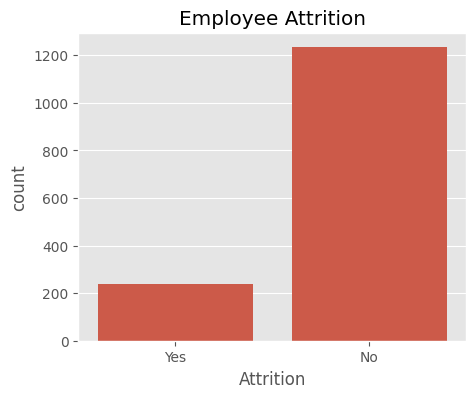

In [ ]:
# Attrition
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='Attrition')
plt.title('Employee Attrition')
plt.show()


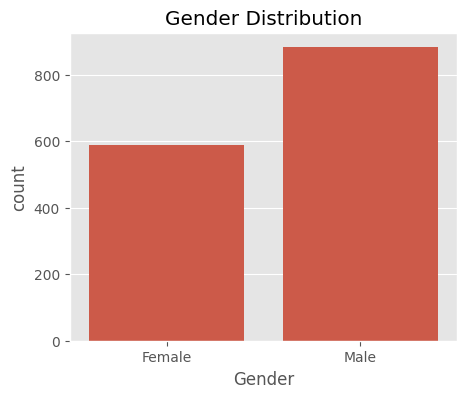

In [ ]:
# Gender
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='Gender')
plt.title('Gender Distribution')
plt.show()


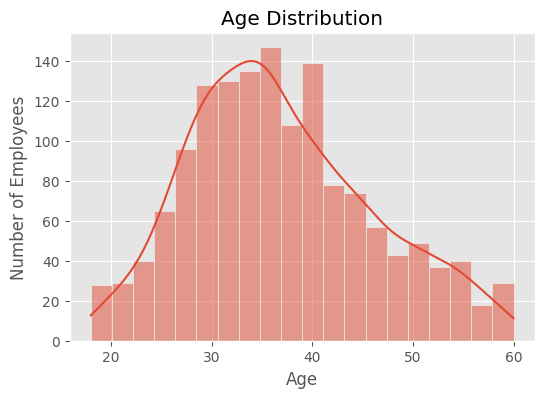

In [31]:

# Age
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()


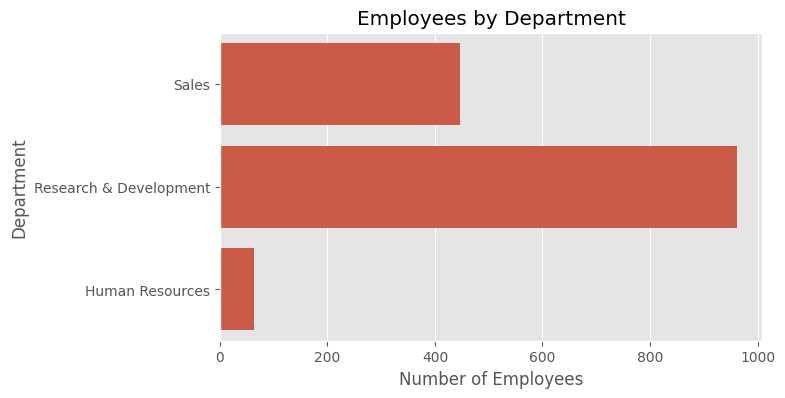

In [32]:
# Department
plt.figure(figsize=(7,4))
sns.countplot(data=df,y='Department')
plt.title('Employees by Department')
plt.ylabel("Department")
plt.xlabel("Number of Employees")
plt.show()


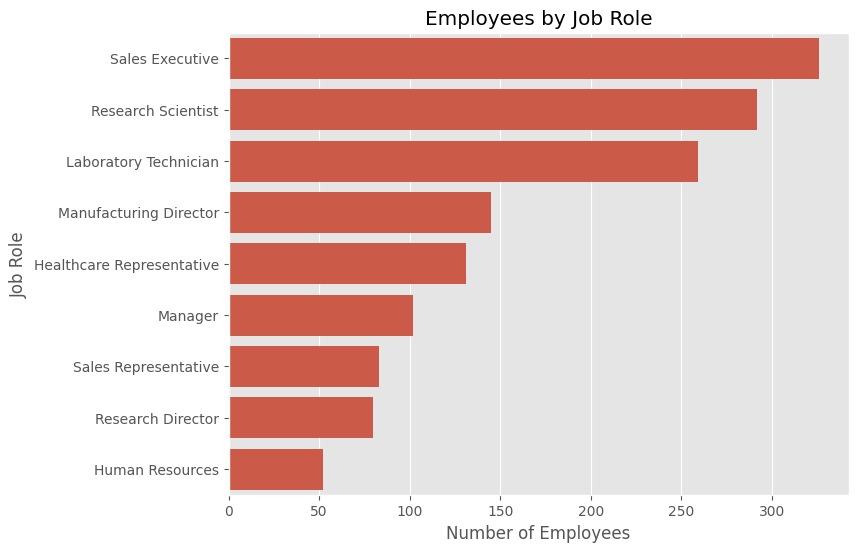

In [34]:
# Job Role
plt.figure(figsize=(8,6))
sns.countplot(data=df,y='JobRole', order=df['JobRole'].value_counts().index)
plt.title('Employees by Job Role')
plt.ylabel("Job Role")
plt.xlabel("Number of Employees")
plt.show()


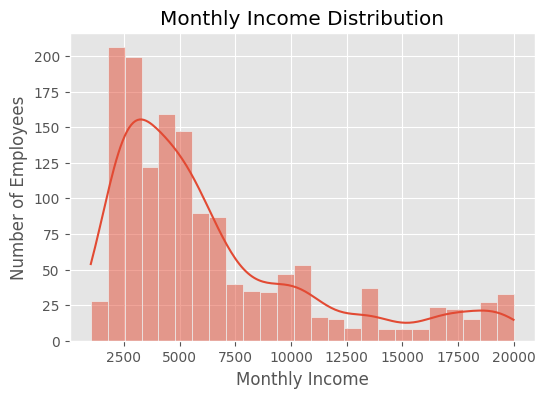

In [35]:
# Monthly Income
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'],bins=25,kde=True)
plt.title('Monthly Income Distribution')
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.show()


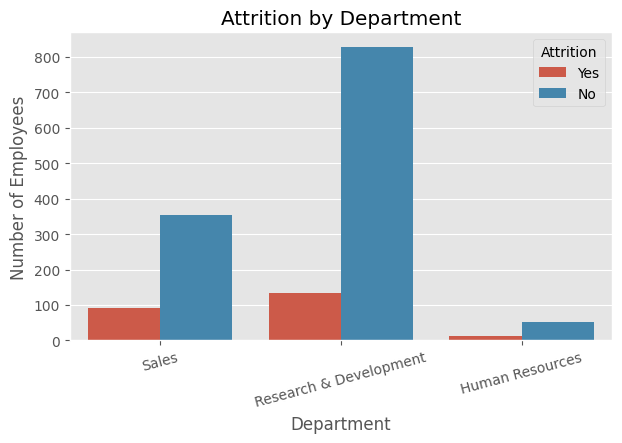

In [36]:
# Attrition by Department
plt.figure(figsize=(7,4))
sns.countplot(data=df,x='Department',hue='Attrition')
plt.xticks(rotation=15)
plt.title('Attrition by Department')
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()


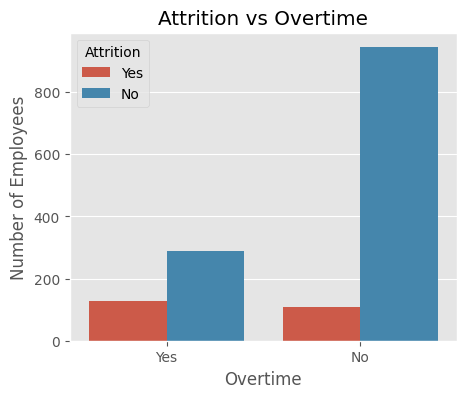

In [37]:
# Attrition by Overtime
plt.figure(figsize=(5,4))
sns.countplot(data=df,x='OverTime',hue='Attrition')
plt.title('Attrition vs Overtime')
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()


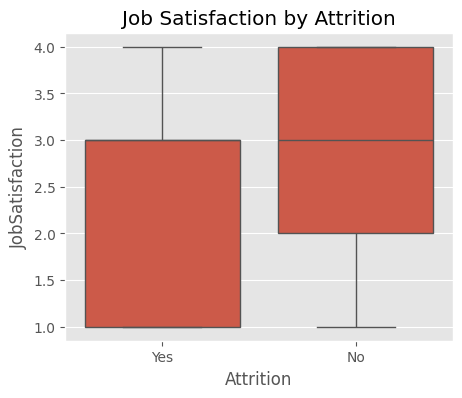

In [ ]:
# Job Satisfaction by Attrition
plt.figure(figsize=(5,4))
sns.boxplot(data=df,x='Attrition',y='JobSatisfaction')
plt.title('Job Satisfaction by Attrition')
plt.show()


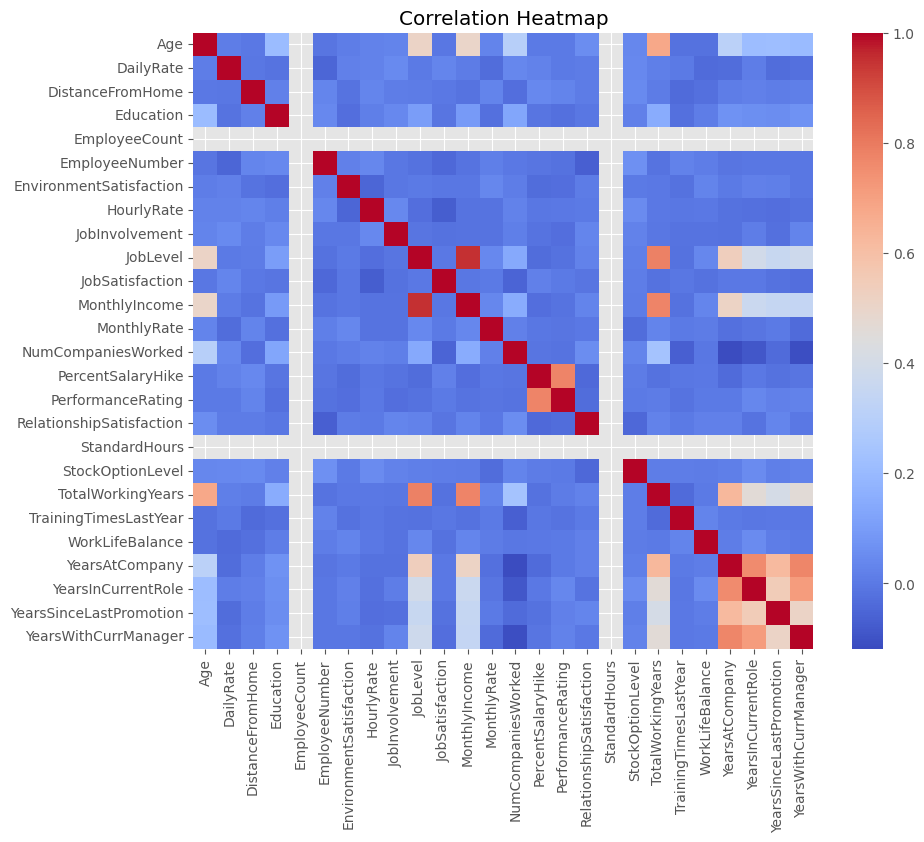

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
corr=df.select_dtypes(include='number').corr()
sns.heatmap(corr,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 4. Business Questions

In [ ]:
# Overall Attrition Rate
attrition_rate = (df['Attrition']=='Yes').mean()*100
print(f'Overall Attrition Rate: {attrition_rate:.2f}%')

print("\nEmployees by Department")
display(df['Department'].value_counts())

print("\nAverage Monthly Income by Department")
display(df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending=False))

print("\nAverage Monthly Income by Job Role")
display(df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False))

print("\nAverage Job Satisfaction by Department")
display(df.groupby('Department')['JobSatisfaction'].mean())

print("\nAverage Years at Company by Attrition")
display(df.groupby('Attrition')['YearsAtCompany'].mean())


Overall Attrition Rate: 16.12%

Employees by Department


,count
Department,
Research & Development,961
Sales,446
Human Resources,63



Average Monthly Income by Department


,MonthlyIncome
Department,
Sales,6959.172646
Human Resources,6654.507937
Research & Development,6281.252862



Average Monthly Income by Job Role


,MonthlyIncome
JobRole,
Manager,17181.676471
Research Director,16033.550000
Healthcare Representative,7528.763359
Manufacturing Director,7295.137931
Sales Executive,6924.279141
Human Resources,4235.750000
Research Scientist,3239.972603
Laboratory Technician,3237.169884
Sales Representative,2626.000000



Average Job Satisfaction by Department


,JobSatisfaction
Department,
Human Resources,2.603175
Research & Development,2.726327
Sales,2.751121



Average Years at Company by Attrition


,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


## Key Insights

1. The overall employee attrition rate is **16.12%**, meaning approximately one out of every six employees has left the organization.

2. The **Research & Development department** has the largest workforce (961 employees), followed by Sales (446 employees) and Human Resources (63 employees).

3. The **Sales department** has the highest average monthly income (₹6,959), followed by Human Resources (₹6,655), while Research & Development has the lowest average salary among the three major departments (₹6,281).

4. **Managers** and **Research Directors** receive the highest average monthly salaries, whereas **Sales Representatives** and **Laboratory Technicians** have the lowest average salaries.

5. Employees who left the company stayed for an average of **5.13 years**, compared to **7.37 years** for employees who remained, indicating that shorter tenure may be associated with higher attrition.

6. The charts suggest that **overtime and job satisfaction** are important factors influencing employee attrition and should be monitored closely.

## Business Recommendations

1. Review workload and overtime policies, especially in departments where attrition is higher, to improve employee well-being.

2. Develop retention programs for employees during their first five years, as employees with shorter tenure are more likely to leave.

3. Review compensation for lower-paid job roles such as Sales Representatives and Laboratory Technicians to improve retention.

4. Conduct regular employee satisfaction surveys and address workplace concerns to improve overall job satisfaction.

5. Continue investing in employee development and career progression opportunities to encourage long-term retention.

6. Monitor department-level attrition regularly so management can identify issues early and implement targeted retention strategies.